In [ ]:
!pip install legacy-cgi opendatasets -q


In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in "./rice-type-classification" (use force=True to force download)


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
data_df.dropna(inplace=True)
data_df.drop(['id'], axis=1, inplace=True)
print(data_df.shape)

(18185, 11)


In [ ]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
print(data_df["Class"].unique())

[1 0]


In [ ]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [ ]:
#Normalize
original_df = data_df.copy()

for column in data_df.columns:
  data_df[column] = data_df[column]/data_df[column].abs().max()


In [ ]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [ ]:
X = data_df.drop(['Class'], axis=1)
y = data_df['Class']

In [ ]:
X

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007
...,...,...,...,...,...,...,...,...,...,...
18180,0.573262,0.811219,0.618156,0.971489,0.545785,0.757140,0.562384,0.654774,0.733291,0.744543
18181,0.742899,0.925674,0.704314,0.971683,0.709121,0.861916,0.730296,0.758107,0.708884,0.745661
18182,0.623408,0.844800,0.640916,0.972058,0.593296,0.789562,0.633098,0.673049,0.754720,0.747830
18183,0.583741,0.826356,0.623551,0.972748,0.562227,0.764030,0.555396,0.675248,0.702103,0.751874


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [ ]:
X_train.shape, X_val.shape, X_test.shape

((12729, 10), (2728, 10), (2728, 10))

In [ ]:
class dataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X.values, dtype=torch.float32).to(device)
    self.y = torch.tensor(y.values, dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

In [ ]:
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [ ]:
train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(validation_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=32, shuffle=True)

In [ ]:
for X, y in train_dataloader:
  print(X)
  print("---")
  print(y)
  break

tensor([[0.6230, 0.9073, 0.6001, 0.9874, 0.5936, 0.7893, 0.5489, 0.7132, 0.6716,
         0.8578],
        [0.7818, 0.8385, 0.8139, 0.9302, 0.7435, 0.8842, 0.6543, 0.7130, 0.8433,
         0.5845],
        [0.5616, 0.8708, 0.5636, 0.9894, 0.5351, 0.7494, 0.7274, 0.6835, 0.6593,
         0.8766],
        [0.5953, 0.8048, 0.6473, 0.9640, 0.5661, 0.7716, 0.9219, 0.6579, 0.7542,
         0.7053],
        [0.5622, 0.8153, 0.6000, 0.9759, 0.5335, 0.7498, 0.5256, 0.6544, 0.7199,
         0.7710],
        [0.8635, 0.8398, 0.8966, 0.9068, 0.8285, 0.9292, 0.7697, 0.7412, 0.8619,
         0.5314],
        [0.7471, 0.7720, 0.8406, 0.9013, 0.7061, 0.8644, 0.6757, 0.6768, 0.8944,
         0.5211],
        [0.5700, 0.8115, 0.6144, 0.9723, 0.5393, 0.7550, 0.7173, 0.6506, 0.7386,
         0.7493],
        [0.4539, 0.6485, 0.6110, 0.9365, 0.4293, 0.6737, 0.5932, 0.5478, 0.8294,
         0.6021],
        [0.6454, 0.8832, 0.6399, 0.9777, 0.6118, 0.8034, 0.5180, 0.7095, 0.7032,
         0.7830],
        [0

In [ ]:
HIDDEN_NEURONS = 10

class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS, 1)
    self.sigmoid = nn.Sigmoid()


  def forward(self, x):
    x = self.input_layer(x)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x

model = MyModel().to(device)

In [ ]:
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [ ]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=1e-3)

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_accuracy_train_plot = []
total_accuracy_validation_plot = []

epochs = 10
for epoch in range(epochs):
  total_acc_train = 0
  total_acc_val = 0
  total_loss_train = 0
  total_loss_val = 0

  for data in train_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)
    batch_loss = criterion(prediction, labels)
    total_loss_train += batch_loss.item()
    acc = (prediction.round() == labels).sum().item()
    total_acc_train += acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in val_dataloader:
      inputs, labels = data

      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels)

      total_loss_val += batch_loss.item()

      acc = (prediction.round() == labels).sum().item()

      total_acc_val += acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_accuracy_train_plot.append(round(total_acc_train/training_data.__len__()*100, 4))
  total_accuracy_validation_plot.append(round(total_acc_val/validation_data.__len__()*100, 4))


  print(f'''Epoch: {epoch+1} Train loss: {round(total_loss_train/1000, 4)}
  Train Accuracy:{round(total_acc_train/training_data.__len__()*100, 4)}
  Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy: {round(total_acc_val/validation_data.__len__()*100, 4)} ''')



Epoch: 1 Train loss: 0.2566 
  Train Accuracy:75.0098 
  Validation Loss: 0.0446 Validation Accuracy: 95.7845 
Epoch: 2 Train loss: 0.1369 
  Train Accuracy:97.5096 
  Validation Loss: 0.0176 Validation Accuracy: 97.8006 
Epoch: 3 Train loss: 0.0604 
  Train Accuracy:98.201 
  Validation Loss: 0.0093 Validation Accuracy: 98.3504 
Epoch: 4 Train loss: 0.0377 
  Train Accuracy:98.3659 
  Validation Loss: 0.0066 Validation Accuracy: 98.607 
Epoch: 5 Train loss: 0.0288 
  Train Accuracy:98.4602 
  Validation Loss: 0.0054 Validation Accuracy: 98.607 
Epoch: 6 Train loss: 0.0243 
  Train Accuracy:98.5466 
  Validation Loss: 0.0049 Validation Accuracy: 98.5337 
Epoch: 7 Train loss: 0.0219 
  Train Accuracy:98.5152 
  Validation Loss: 0.0044 Validation Accuracy: 98.607 
Epoch: 8 Train loss: 0.0203 
  Train Accuracy:98.6016 
  Validation Loss: 0.0043 Validation Accuracy: 98.607 
Epoch: 9 Train loss: 0.0192 
  Train Accuracy:98.5623 
  Validation Loss: 0.004 Validation Accuracy: 98.5704 
Epoch: 

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for data in test_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)
    batch_loss_test = criterion(prediction, labels)
    total_loss_test += batch_loss_test.item()

    acc = (prediction.round() == labels).sum().item()
    total_acc_test += acc

print("Accuracy:", round(total_acc_test/testing_data.__len__()*100, 4))

Accuracy: 99.0469


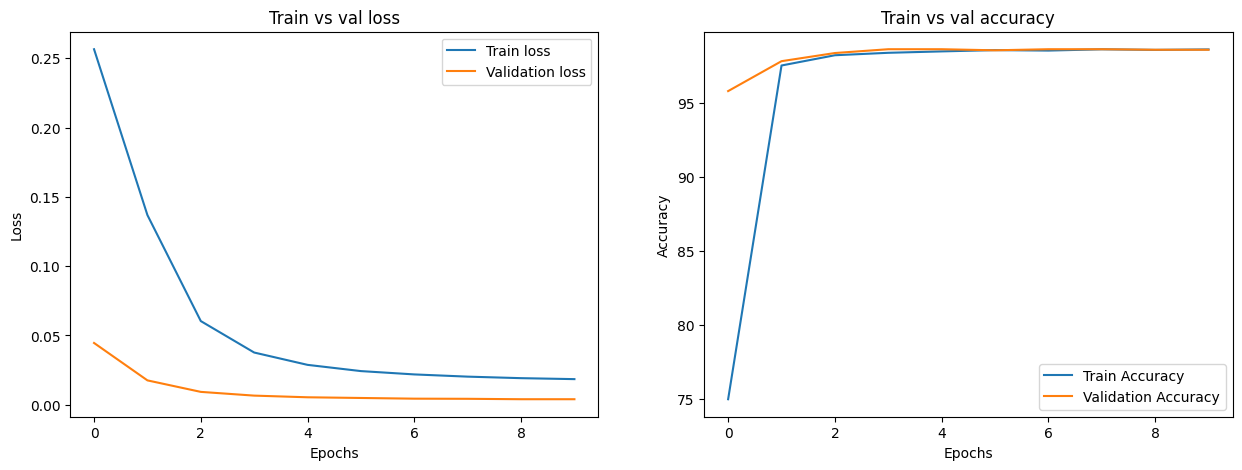

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
axs[0].plot(total_loss_train_plot, label="Train loss")
axs[0].plot(total_loss_validation_plot, label="Validation loss")
axs[0].set_title("Train vs val loss")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_accuracy_train_plot, label="Train Accuracy")
axs[1].plot(total_accuracy_validation_plot, label="Validation Accuracy")
axs[1].set_title("Train vs val accuracy")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.show()
